In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy.stats import kruskal, chi2_contingency
import re

SOLO PER TESTARE LA CORRETTEZZA DEL SALVATAGGIO DEI CLUSTER

In [3]:
# --- Funzione 0: T-SNE ---
def plot_tsne(
    X,
    labels=None,
    outlier_label=-1,
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,
    random_state=42,
    figsize=(10, 8),
    title="t-SNE Visualization",
    point_size=50
):
    tsne = TSNE(
        n_components=n_components,
        perplexity=perplexity,
        learning_rate=learning_rate,
        max_iter=max_iter,
        random_state=random_state
    )

    X_tsne = tsne.fit_transform(X)

    plt.figure(figsize=figsize)

    if labels is None:
        plt.scatter(
            X_tsne[:, 0],
            X_tsne[:, 1],
            s=point_size,
            alpha=0.8,
            edgecolor="black",
            linewidth=0.3
        )
    else:
        labels = np.array(labels)
        unique_labels = np.unique(labels)
        cluster_labels = [l for l in unique_labels if l != outlier_label]

        n_clusters = len(cluster_labels)

        # === PALETTE COLORI VIVACI ===
        if n_clusters <= 9:
            base_colors = plt.get_cmap("Set1").colors
            colors = base_colors[:n_clusters]
        else:
            # fallback per molti cluster
            colors = plt.cm.hsv(np.linspace(0, 1, n_clusters))

        color_map = {cls: colors[i] for i, cls in enumerate(cluster_labels)}

        for cls in unique_labels:
            idx = labels == cls

            if cls == outlier_label:
                plt.scatter(
                    X_tsne[idx, 0],
                    X_tsne[idx, 1],
                    c="lightgray",
                    s=point_size,
                    alpha=0.5,
                    label="Outlier"
                )
            else:
                plt.scatter(
                    X_tsne[idx, 0],
                    X_tsne[idx, 1],
                    c=[color_map[cls]],
                    s=point_size,
                    alpha=0.9,
                    label=f"Cluster {cls}",
                    edgecolor="black",
                    linewidth=0.4
                )

        plt.legend(
            title="Cluster label",
            # bbox_to_anchor=(1.05, 1),
            loc="upper right",
            fontsize="x-small",
            markerscale=1.3
        )

    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

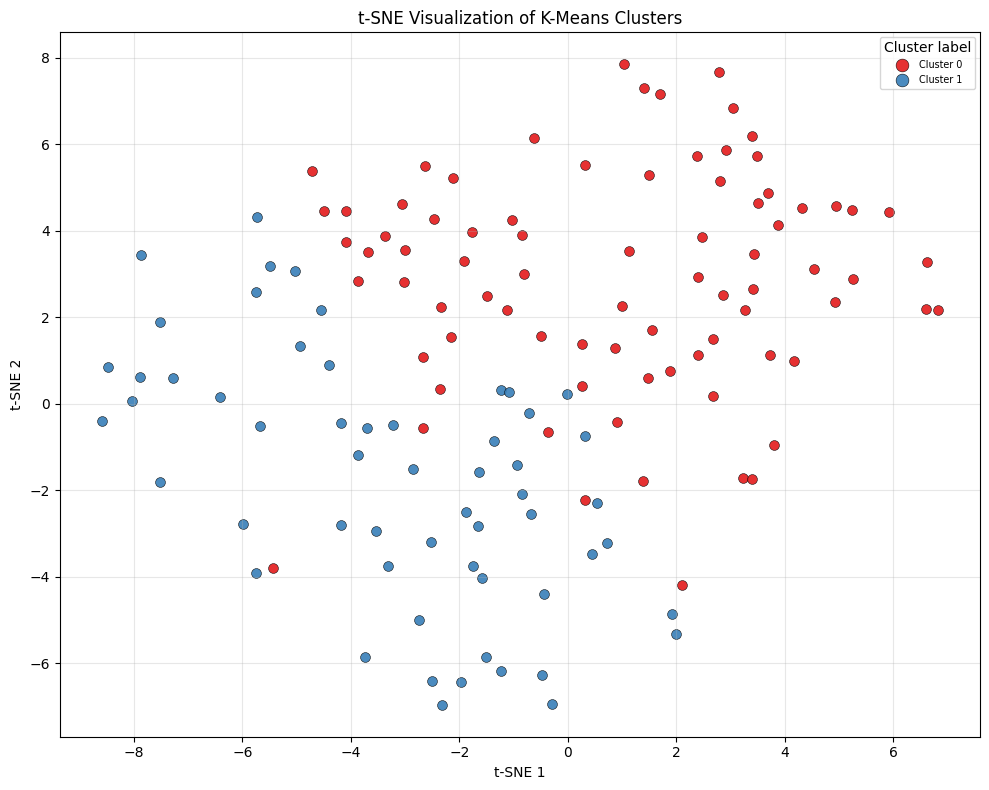

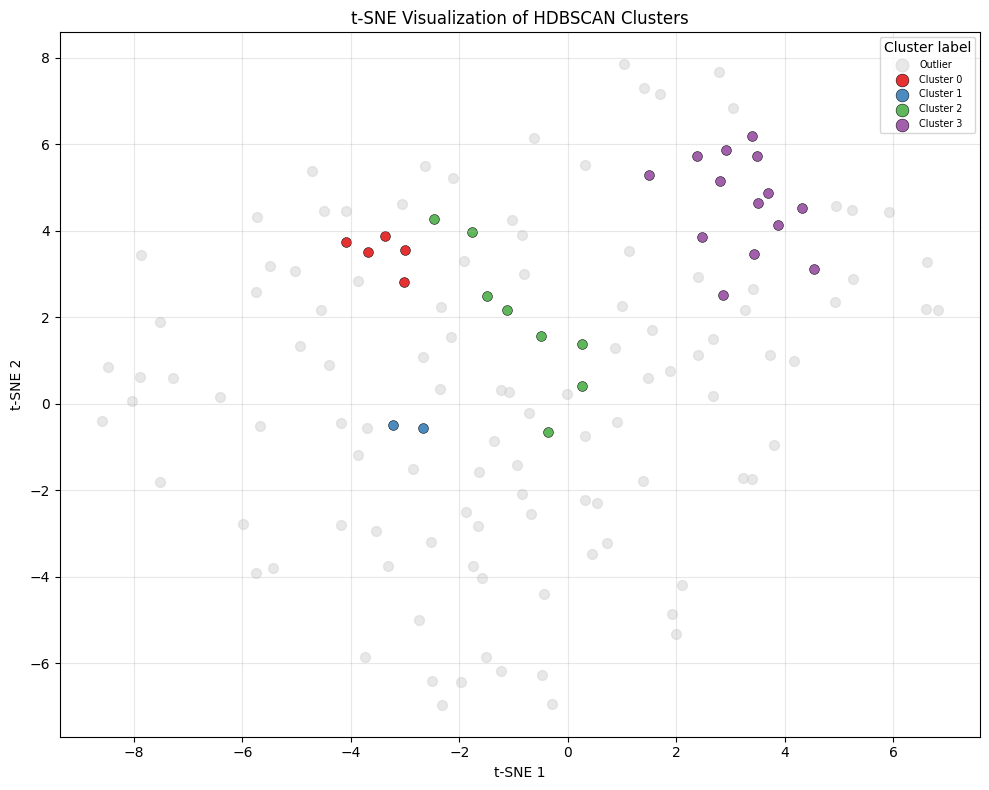

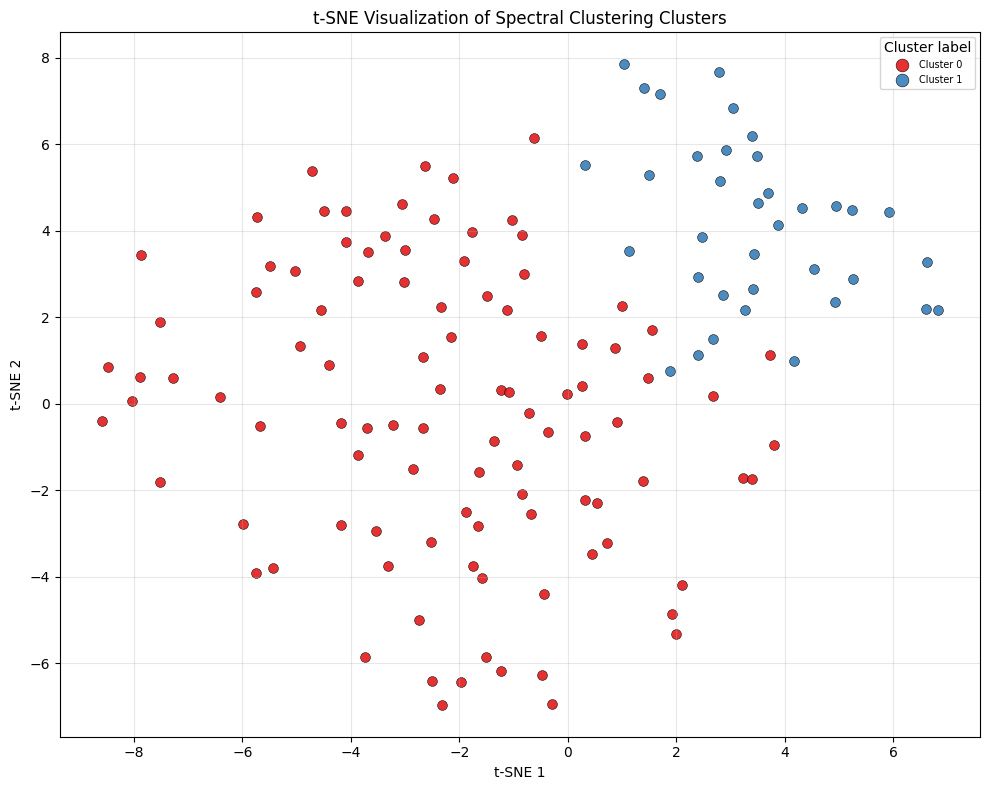

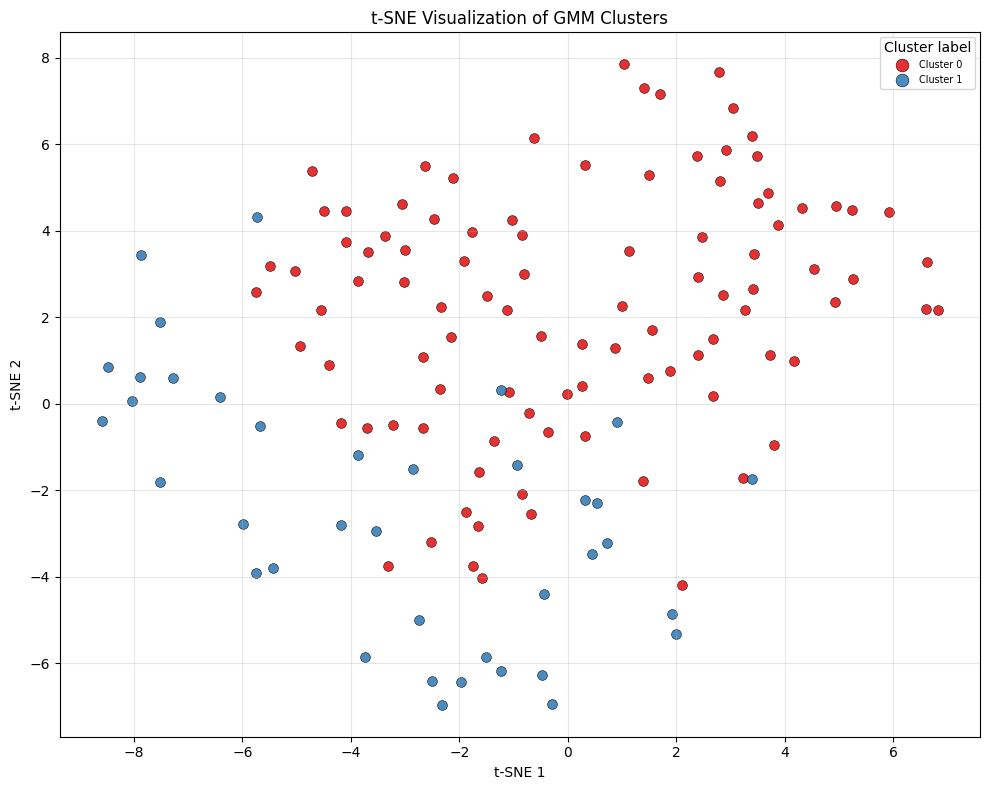

In [4]:
# Percorsi
base_path = Path(".")
factors_path = base_path / "PDAC_DATA_MOFA_DATA" / "df_factors.csv"
clusters_path = base_path / "PDAC_DATA_CLUSTERING" / "clusters.csv"

# Lettura dataset
df_factors = pd.read_csv(factors_path, index_col=0)
df_clusters = pd.read_csv(clusters_path, index_col=0)

# Controllo coerenza
assert len(df_factors) == len(df_clusters), "Numero di campioni non coerente"


# Loop su ogni tecnica di clustering
for clustering_method in df_clusters.columns:
    
    # Estrae una singola colonna come Series
    labels = df_clusters[clustering_method]
    
    # (opzionale) assicurati che l'indice combaci
    labels = labels.loc[df_factors.index]
    
    # Passa i due input separati alla funzione
    plot_tsne(
        df_factors,
        labels,
        title=f"t-SNE Visualization of {clustering_method} Clusters"
    )



Si analizza il clustering prodotto da HDBSCAN

In [10]:
# Cluster Validation: Statistical Post-Hoc Testing
# Kruskal-Wallis for numeric, Chi-Square for categorical

# caricamento della matrice dei fattori MOFA
df_factors = pd.read_csv("PDAC_DATA_MOFA_DATA/df_factors.csv", index_col=0)
clinical_df = pd.read_csv("PDAC_data/clinical_data.csv",index_col=0)
clusters_df = pd.read_csv("PDAC_DATA_CLUSTERING/clusters.csv", index_col=0)

# warnings.filterwarnings("ignore")

# significance level
ALPHA = 0.05

# outlier clusters to remove
OUTLIER_CLUSTERS = [-1] 

# variable type definitions
CATEGORICAL_COLS = [
    'histology_diagnosis', 'race', 'participant_country', 'tumor_site', 
    'tumor_necrosis', 'pathologic_staging_regiol_lymph_nodes_pn',
    'pathologic_staging_primary_tumor_pt', 'pathologic_staging_distant_metastasis_pm',
    'clinical_staging_distant_metastasis_cm', 'residual_tumor',
    'tumor_stage_pathological', 'alcohol_consumption', 'tobacco_smoking_history',
    'cause_of_death', 'lymph_vascular_invasion'
]
NUMERIC_COLS = [
    'age', 'bmi', 'tumor_size_cm', 'follow_up_days'
]
BINARY_COLS = [
    'sex', 'vital_status', 'perineural_invasion', 
    'is_this_patient_lost_to_follow_up'
]

# Merge dei dati
df_validation = clinical_df.join(df_factors, how='inner')
df_validation['cluster'] = clusters_df['HDBSCAN']

MOFA_FACTORS = df_factors.columns.tolist()

# Rimozione outlier clusters se presenti
if OUTLIER_CLUSTERS:
    df_validation = df_validation[~df_validation['cluster'].isin(OUTLIER_CLUSTERS)]

# Assicuriamoci che 'cluster' sia trattato come categoria
df_validation['cluster'] = df_validation['cluster'].astype(str)
clusters = df_validation['cluster'].unique()
# print(df_validation.columns)
results_numeric = []

numeric_cols_to_test = MOFA_FACTORS + \
                        [col for col in NUMERIC_COLS if col in df_validation.columns] +\
                        [col for col in BINARY_COLS if col in df_validation.columns]
categorical_cols_to_test = [col for col in CATEGORICAL_COLS if col in df_validation.columns]

# colonne numeriche, binarie e fattori
for col in numeric_cols_to_test:
    if col in df_validation.columns:
        # Prepariamo i gruppi (rimuovendo i NaN per ogni colonna)
        groups = [df_validation[df_validation['cluster'] == c][col].dropna() for c in clusters]
        
        # Eseguiamo il test solo se abbiamo almeno 2 gruppi validi
        if len(groups) > 1 and all(len(g) > 0 for g in groups):
            stat, p_val = kruskal(*groups)
            results_numeric.append({
                'Variable': col,
                'Test': 'Kruskal-Wallis',
                'Statistic': stat,
                'p-value': p_val,
                'Significant': p_val < ALPHA
            })

df_res_num = pd.DataFrame(results_numeric)

results_categorical = []

# variabili categoriche
for col in categorical_cols_to_test:
    if col in df_validation.columns:
        # Creazione tabella di contingenza (Cluster vs Variabile)
        contingency_table = pd.crosstab(df_validation['cluster'], df_validation[col])
        
        # Il test chi-square richiede che la tabella non sia vuota
        if not contingency_table.empty:
            chi2, p_val, dof, ex = chi2_contingency(contingency_table)
            results_categorical.append({
                'Variable': col,
                'Test': 'Chi-Square',
                'Statistic': chi2,
                'p-value': p_val,
                'Significant': p_val < ALPHA
            })

df_res_cat = pd.DataFrame(results_categorical)

# Unione dei risultati per una visione d'insieme
all_results = pd.concat([df_res_num, df_res_cat], ignore_index=True)

# Filtra solo i risultati significativi (p < 0.05)
significant_vars = all_results.sort_values(by='p-value')
significant_vars.to_excel('./exported_data/MOFA_significant_variables.xlsx', sheet_name='Significant_Variables')

print("--- Variabili Significative che differenziano i Cluster ---")
print(significant_vars[['Variable', 'p-value', 'Significant']])

--- Variabili Significative che differenziano i Cluster ---
                                    Variable   p-value  Significant
0                                    Factor1  0.000071         True
1                                    Factor2  0.000149         True
6                                    Factor7  0.000403         True
29    clinical_staging_distant_metastasis_cm  0.006556         True
4                                    Factor5  0.012188         True
26  pathologic_staging_regiol_lymph_nodes_pn  0.041199         True
10                                  Factor11  0.049386         True
2                                    Factor3  0.054093        False
12                                  Factor13  0.066776        False
28  pathologic_staging_distant_metastasis_pm  0.066937        False
5                                    Factor6  0.069829        False
19                       perineural_invasion  0.089040        False
27       pathologic_staging_primary_tumor_pt  0.090123  

Il test precedente verifica se le differenze tra i diversi cluster individuati sono significative.
Per le variabili numeriche viene eseguito il test di Kruskal-Wallis, mentre per le var. categoriche il test Chi-square.
Un valore di p-value basso per una caratteristica, indica che quella caratteristica ha un grande peso nella distinzione in gruppi (cluster).

Outlier clusters removed: [-1]. Analysis on clusters: ['0', '1', '2', '3']
Found 15 categorical variables to profile.


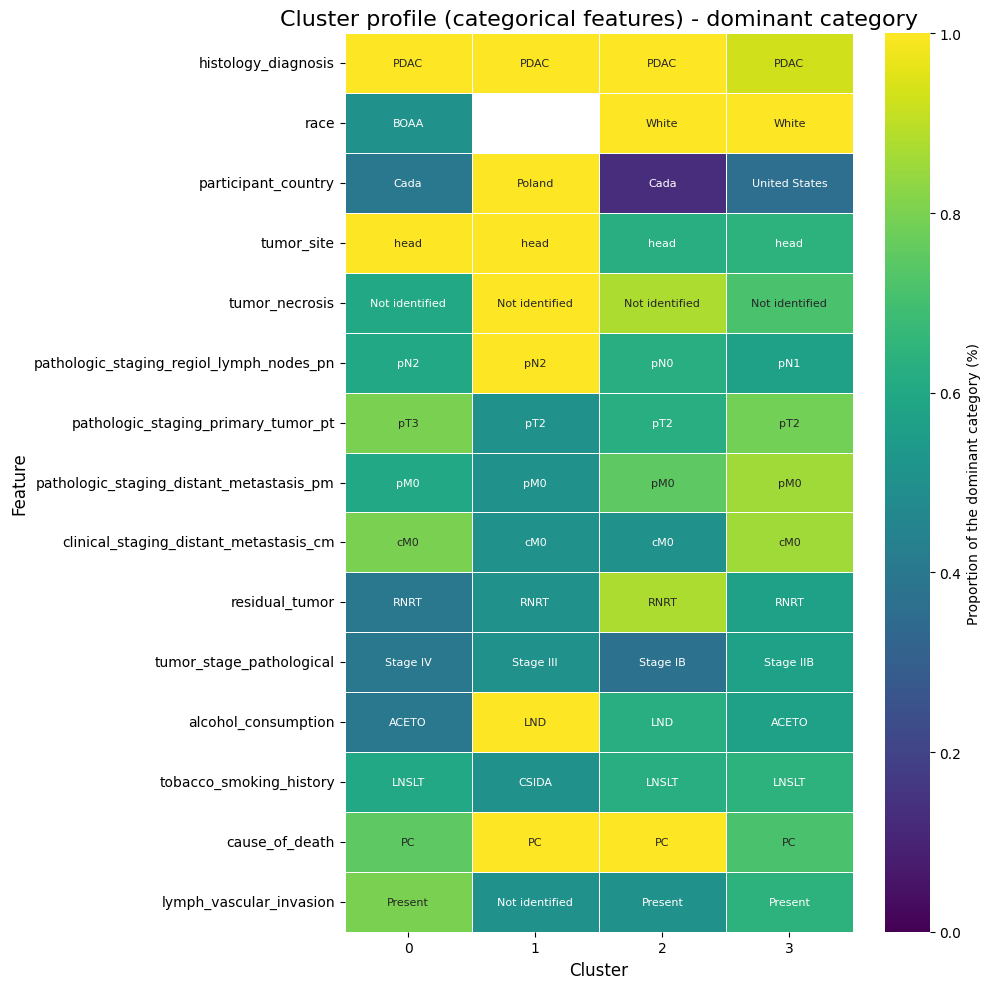


--- Acronym legend ---
BOAA  : Black or African American
RNRT  : R0:  No residual tumor
ACETO : Alcohol consumption equal to or less than 2 drinks per day for men and 1 drink or less per day for women
LND   : Lifelong non-drinker
LNSLT : Lifelong non-smoker: Less than 100 cigarettes smoked in lifetime
CSIDA : Current smoker: Includes daily and non-daily smokers
PC    : pancreatic carcinoma


In [ ]:
# plot of categorical features distributions per cluster

analysis_df_filtered = df_validation[~df_validation['cluster'].isin(OUTLIER_CLUSTERS)].copy()
clusters_to_profile = sorted(analysis_df_filtered['cluster'].unique())
print(f"Outlier clusters removed: {OUTLIER_CLUSTERS}. Analysis on clusters: {clusters_to_profile}")

vars_to_run = [col for col in CATEGORICAL_COLS if col in analysis_df_filtered.columns]
print(f"Found {len(vars_to_run)} categorical variables to profile.")

# acronym logic to avoid long labels in heatmap
MAX_LEN = 18        # max length before acronym is created
acronym_legend = {} # dictionary to store acronyms and their full forms
def make_acronym(text):
    if not isinstance(text, str):
        return str(text)
    text = re.sub(r'\(.*\)', '', text)
    parts = re.split(r'[\s_\-:]+', text)
    acronym = "".join([part[0].upper() for part in parts if part])[:5]
    return acronym

# prepare heatmap data structures
heatmap_mode = pd.DataFrame(index=vars_to_run, columns=clusters_to_profile, dtype=object)
heatmap_proportion = pd.DataFrame(index=vars_to_run, columns=clusters_to_profile, dtype=float)

# iterate over variables and clusters to compute mode and proportion
for var in vars_to_run:
    for cluster in clusters_to_profile:
        cluster_data = analysis_df_filtered[analysis_df_filtered['cluster'] == cluster][var].dropna()
        
        if cluster_data.empty:
            heatmap_mode.loc[var, cluster] = "N/A"
            heatmap_proportion.loc[var, cluster] = np.nan
            continue
            
        mode_val = cluster_data.mode().iloc[0]
        proportion = (cluster_data == mode_val).mean()
        
        display_val = str(mode_val)
        if len(display_val) > MAX_LEN:
            acronym = make_acronym(display_val)
            original_acronym = acronym
            count = 1
            while acronym in acronym_legend and acronym_legend[acronym] != display_val:
                acronym = f"{original_acronym}{count}"
                count += 1
            
            acronym_legend[acronym] = display_val
            display_val = acronym
            
        heatmap_mode.loc[var, cluster] = display_val
        heatmap_proportion.loc[var, cluster] = proportion

# plot heatmap
heatmap_proportion = heatmap_proportion.astype(float)
plt.figure(figsize=(10, 10))
sns.heatmap(
    heatmap_proportion, 
    annot=heatmap_mode,
    fmt='s',
    cmap='viridis',
    vmin=0.0,
    vmax=1.0,
    linewidths=.5,
    cbar_kws={'label': 'Proportion of the dominant category (%)'},
    annot_kws={"size": 8}
)
plt.title('Cluster profile (categorical features) - dominant category', fontsize=16)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'../img/RES_cluster_profile_categorical_dominant.png', dpi=300, bbox_inches='tight')
plt.show()

if acronym_legend:
    print("\n--- Acronym legend ---")
    #print("(printed because some labels were > 18 characters)")
    max_key_len = max(len(k) for k in acronym_legend.keys())
    for acr, full_text in acronym_legend.items():
        print(f"{acr:<{max_key_len}} : {full_text}")

Il blocco precedente cerca la moda per ogni cluster e variabile categorica, indicando poi in una heatmap quanto ciascuna variabile è rappresentativa per il cluster.
- Moda: qual è il valore più frequente per ciascuna variabile all'interno del cluster.
- Proporzione: in quale percentuale il valore più frequente è presente.
Colori verso il giallo indicano che quasi tutti i pazienti presentano quel valore per quella caratteristica, valori scuri indicano invece un cluster con valori più variati.

Outlier clusters removed: [-1]. Analysis on clusters: ['0', '1', '2', '3']
Found 8 numerical/binary variables to profile.


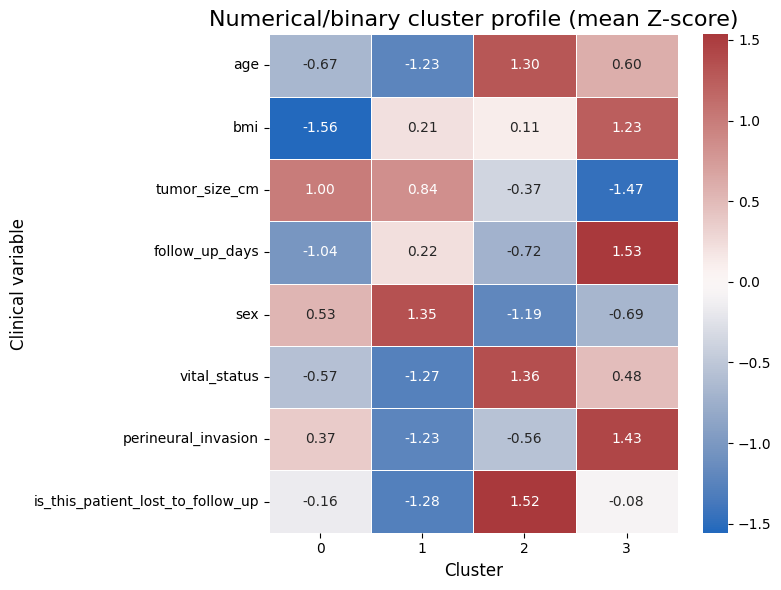

In [ ]:
# plot of numerical and binary features profiles per cluster

analysis_df_filtered = df_validation[~df_validation['cluster'].isin(OUTLIER_CLUSTERS)].copy()
clusters_to_profile = sorted(analysis_df_filtered['cluster'].unique())
print(f"Outlier clusters removed: {OUTLIER_CLUSTERS}. Analysis on clusters: {clusters_to_profile}")

cols_to_profile = [col for col in (NUMERIC_COLS + BINARY_COLS) if col in analysis_df_filtered.columns]
print(f"Found {len(cols_to_profile)} numerical/binary variables to profile.")

df_num_profile = analysis_df_filtered.copy()

le = LabelEncoder()

# Encode binary categorical variables
for col in BINARY_COLS:
    if col in df_num_profile.columns and not pd.api.types.is_numeric_dtype(df_num_profile[col]):
         # Nan handling: fill NaN with a placeholder before encoding
        df_num_profile[col] = df_num_profile[col].fillna('Missing')
        df_num_profile[col] = le.fit_transform(df_num_profile[col])

# compute mean per cluster
cluster_stats = df_num_profile.groupby('cluster')[cols_to_profile].mean()

# apply z-score normalization across clusters for each variable
scaler = StandardScaler()
stats_scaled = scaler.fit_transform(cluster_stats)
stats_scaled_df = pd.DataFrame(
    stats_scaled, 
    index=cluster_stats.index, 
    columns=cluster_stats.columns
)

# plot heatmap
plt.figure(figsize=(max(8, len(clusters_to_profile) * 1.5), max(6, len(cols_to_profile) * 0.5)))
sns.heatmap(
    stats_scaled_df.T,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    linewidth=0.5
)
plt.title("Numerical/binary cluster profile (mean Z-score)", fontsize=16)
plt.ylabel("Clinical variable", fontsize=12)
plt.xlabel("Cluster", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'../img/RES_cluster_profile_numerical_binary.png', dpi=300, bbox_inches='tight')
plt.show()

Il blocco precedente vuole individuare i profili delle feature numeriche e binarie per ciascun cluster.
I pazienti vengono raggruppati per cluster e viene calcolata la media di ciascuna feature numerica e binaria.
I valori medi sono poi standardizzati con Z-score e visualizzati in una heatmap.

Outlier clusters removed: [-1]. Analysis on clusters: ['0', '1', '2', '3']

Mean factor profile per cluster (Z-scores):
|   cluster |   Factor1 |   Factor2 |   Factor3 |   Factor4 |   Factor5 |   Factor6 |   Factor7 |   Factor8 |   Factor9 |   Factor10 |   Factor11 |   Factor12 |   Factor13 |
|----------:|----------:|----------:|----------:|----------:|----------:|----------:|----------:|----------:|----------:|-----------:|-----------:|-----------:|-----------:|
|         0 |     0.162 |     1.213 |     1.053 |    -0.375 |     0.796 |    -0.029 |    -0.553 |     0.042 |    -0.208 |     -0.045 |      0.016 |     -0.062 |     -0.081 |
|         1 |    -0.000 |     1.766 |    -0.404 |    -0.968 |    -0.305 |     0.475 |     0.250 |     0.084 |     0.023 |     -0.155 |      0.143 |      0.148 |     -0.252 |
|         2 |     0.400 |     0.180 |     0.590 |     0.044 |    -0.463 |     0.196 |    -0.202 |     0.040 |    -0.152 |     -0.004 |      0.008 |     -0.080 |     -0.301 |
|         

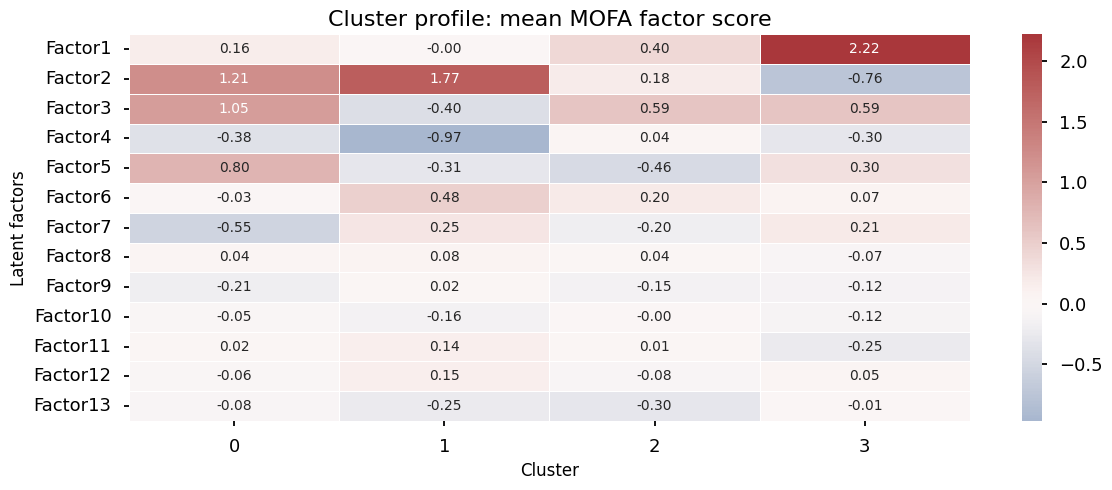

In [ ]:
# cluster profiling based on MOFA factors

analysis_df_filtered = df_validation[~df_validation['cluster'].isin(OUTLIER_CLUSTERS)].copy()
clusters_to_profile = sorted(analysis_df_filtered['cluster'].unique())
print(f"Outlier clusters removed: {OUTLIER_CLUSTERS}. Analysis on clusters: {clusters_to_profile}")

# compute mean factor scores per cluster
factor_columns = df_factors.columns.tolist()
cluster_factor_profiles = analysis_df_filtered.groupby('cluster')[factor_columns].mean()
print("\nMean factor profile per cluster (Z-scores):")
print(cluster_factor_profiles.to_markdown(floatfmt=".3f"))


# heatmap of factor profiles per cluster
plt.style.use('seaborn-v0_8-talk')
plt.figure(figsize=(12, 5))
sns.heatmap(
    cluster_factor_profiles.T, 
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    linewidth=0.5
)

plt.title("Cluster profile: mean MOFA factor score", fontsize=16)
plt.ylabel("Latent factors", fontsize=12)
plt.xlabel("Cluster", fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'../img/RES_cluster_profile_MOFA_factors.png', dpi=300, bbox_inches='tight')
plt.show()

Nel blocco precedente si sposta l'attenzione dalla clinica alla biologia, cercando di individuare i motori molecolari che definiscono ogni cluster.
Presi i fattori MOFA, viene calcolato il valor medio di ciascun fattore all'interno di ogni cluster. I valori sono poi standardizzati con Z-score e rappresentati in una heatmap.

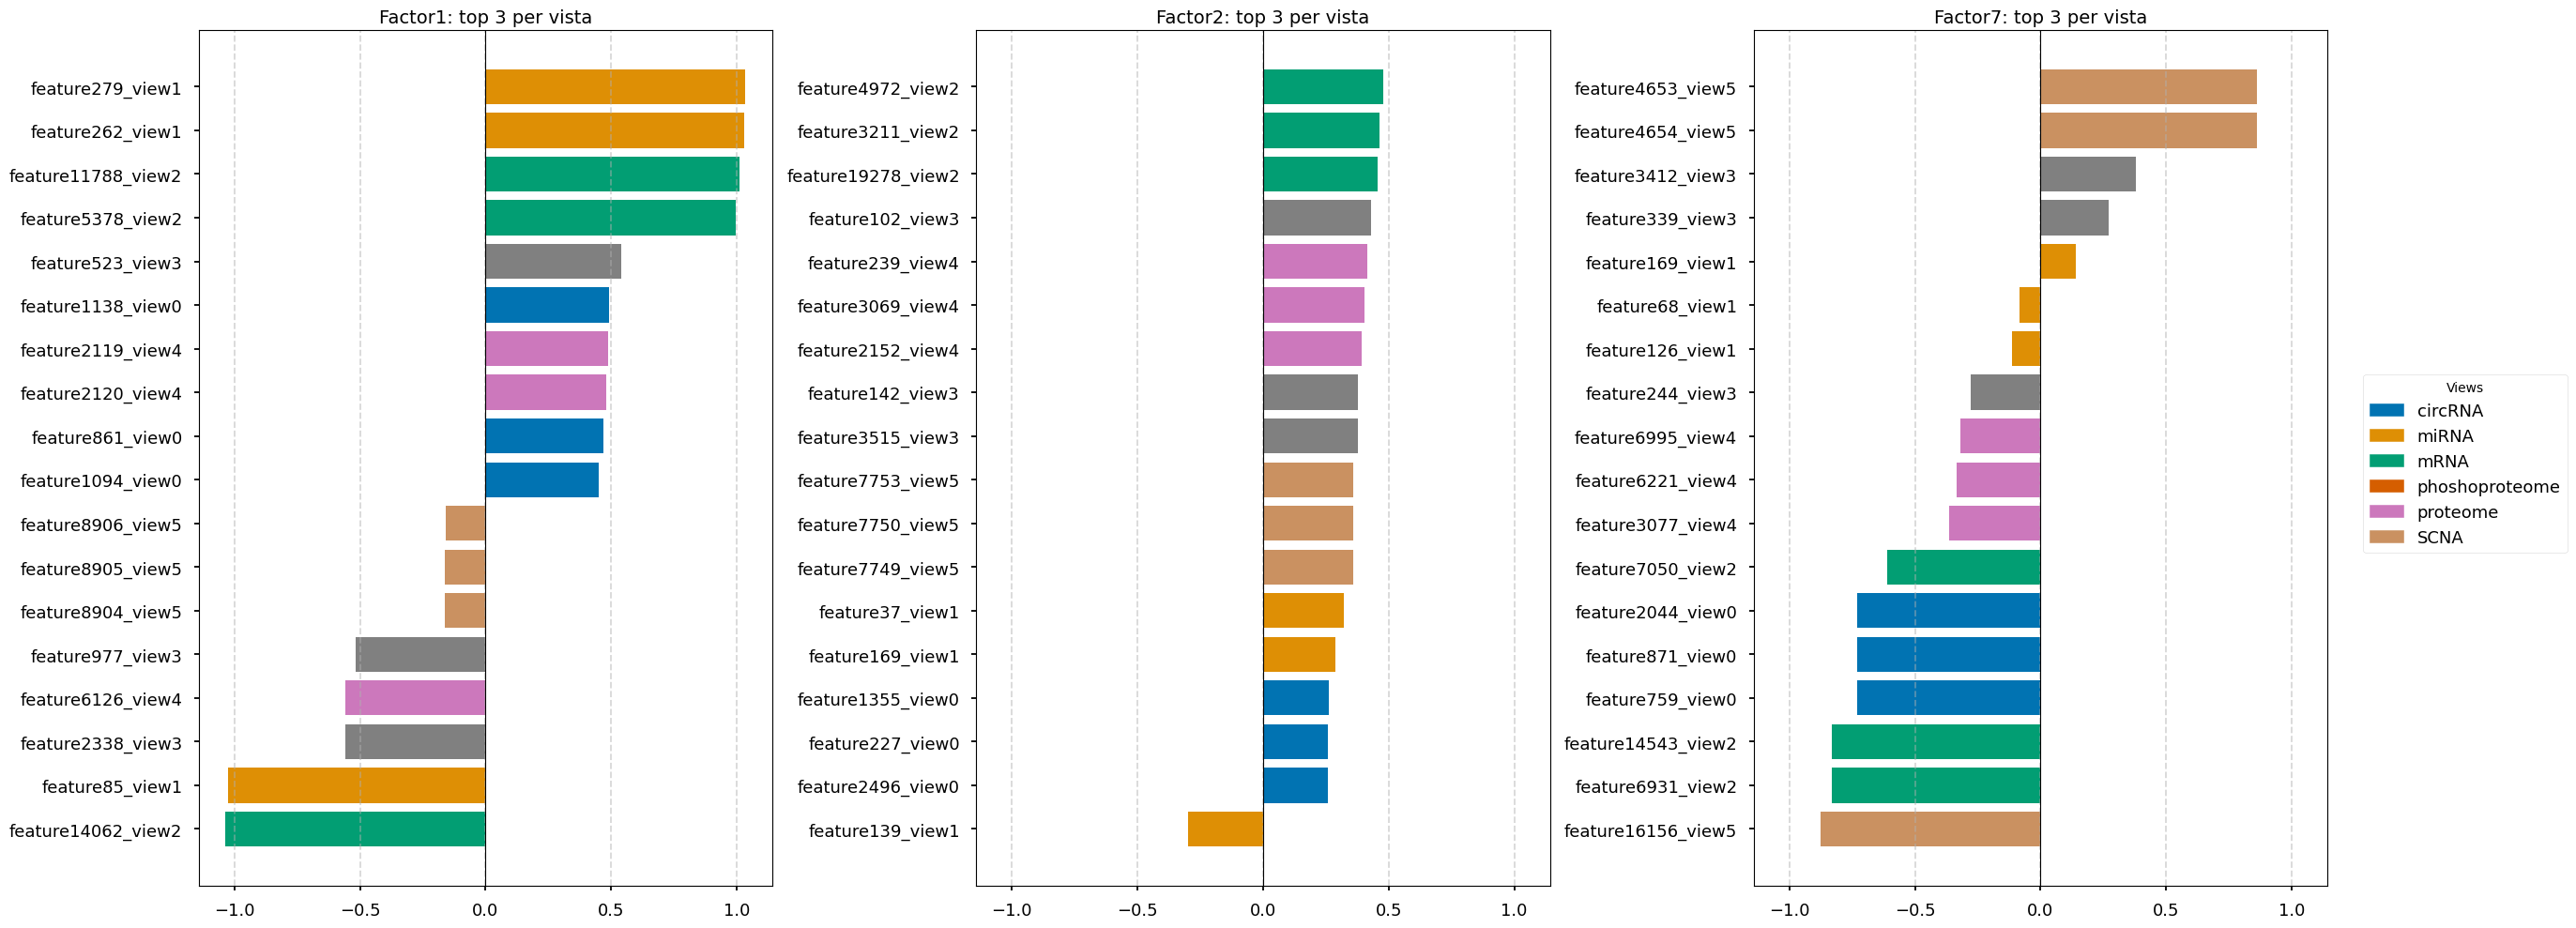

In [ ]:
import mofax
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Caricamento modello
model_file = r"model/mofa_model.hdf5"
model = mofax.mofa_model(model_file)

# scelgo i fattori con p-value maggiore (qualche blocco sopra)
factors_to_analyze = ["Factor1", "Factor2", "Factor7"]
N_top_features = 3 

labels = ['circRNA', 'miRNA', 'mRNA', 'phoshoproteome', 'proteome', 'SCNA']
# Creazione dizionario colori con controllo spazi
view_colors_dict = dict(zip(labels, sns.color_palette("colorblind", n_colors=len(labels))))

plot_data = [] 
global_max_weight = 0

for factor in factors_to_analyze:
    top_features_df = model.get_top_features(
        factors=factor,
        n_features=N_top_features,
        df=True
    )
    
    if not top_features_df.empty:
        current_max = top_features_df["value"].abs().max()
        if current_max > global_max_weight:
            global_max_weight = current_max
        plot_data.append(top_features_df)
    else:
        plot_data.append(pd.DataFrame()) # Mantieni l'indice per il loop successivo

limit = global_max_weight * 1.1
fig, axes = plt.subplots(1, 3, figsize=(25, 10)) 

for i, factor_name in enumerate(factors_to_analyze):
    ax = axes[i]
    df = plot_data[i]

    if df.empty:
        ax.set_title(f"{factor_name}\n(Vuoto)")
        ax.axis('off')
        continue

    # Pulizia nomi feature
    # Usiamo una regex sicura per rimuovere il suffisso della vista
    pattern = '|'.join(labels)
    df["feature_clean"] = df["feature"].str.replace(f"_(?:{pattern})$", "", regex=True)
    df = df.sort_values(by="value")

    # Mappatura colori con fallback su grigio se il nome vista non combacia perfettamente
    colors = df["view"].map(view_colors_dict).fillna("gray")

    ax.barh(df["feature_clean"], df["value"], color=colors)
    
    ax.set_xlim(-limit, limit)
    ax.set_title(f"{factor_name}: top {N_top_features} per vista", fontsize=14)
    ax.axvline(0, color='black', linestyle='-', linewidth=0.8)
    ax.grid(axis="x", linestyle="--", alpha=0.5)

# Legenda migliorata
handles = [plt.Rectangle((0,0),1,1, color=view_colors_dict[l]) for l in labels]
fig.legend(handles, labels, title="Views", loc='center right', bbox_to_anchor=(1.1, 0.5))

plt.tight_layout()
plt.savefig(f'../img/RES_MOFA_factors_top_features.png', dpi=300, bbox_inches='tight')
plt.show()
model.close()